# Level 1 — Single-Nucleus Census of an Adult Glioblastoma

## CAJAL "Neuromics 2026" — Computational Mini-Project C10 (Level 1)

**Estimated time:** ~2 days

**Learning objectives**
- Load and explore single-nucleus RNA-seq (snRNA-seq) data in the AnnData format
- Perform quality control on nuclei and understand what has *already* been done to the data
- Normalize, select features, and integrate across donors (Harmony **and** scVI, compared)
- Cluster and annotate broad cell types using marker genes **and** an automated classifier
- Separate malignant cells from the non-malignant tumour microenvironment (TME) using copy-number inference
- Characterise a continuous **malignant cell-state axis** and how it varies between donors

**Dataset:** snRNA-seq (10x Multiome, RNA modality) from **two adult patients** with high-grade glioma — donors `AT10` and `AT14`, sampled from several tissue sites each. `~118,000` nuclei × `~36,600` genes. The expression matrix holds **raw integer UMI counts**.

> **We are not telling you where this data comes from yet.** There is no paper, title, or figure to look up. Your job is to let the data speak: reconstruct the cell types and tumour states yourself, the way the original analysts had to. The "reveal" happens in Level 2.

---

## 0. Setup

In [1]:
# --- Setup -----------------------------------------------------------------
# WHAT & WHY: import the libraries you'll use throughout and set display defaults.
# HOW: import scanpy as sc, numpy as np, pandas as pd, matplotlib.pyplot as plt;
#      also `import gbmspace_utils as gu` (project helpers). sc.settings.set_figure_params(dpi=80) is handy.
# DOCS: https://scanpy.readthedocs.io/en/stable/usage-principles.html


In [2]:
import scanpy as sc
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
# import gbmspace_utils as gu

sc.settings.set_figure_params(dpi=80)

## 1. Load and explore the data

🔬 **TASK 1.1:** Load the snRNA-seq dataset and inspect the AnnData object — shape, `.obs` columns, and confirm what is stored in `.X`.

In [3]:
DATA = "/shared/projects/tp_2630_ubordeaux_neuromics_184418/projects/C10/data/snRNA_seq/level1_prepared/gbm_l1_snrna_AT10_AT14_raw.h5ad"

# Your code for: Load the snRNA-seq dataset and inspect the AnnData object — shape, `.obs` columns, and confirm what is stored in `.X`


In [4]:
# --- 1. Load and explore ---------------------------------------------------
# WHAT & WHY: read the AnnData and get oriented (nuclei x genes, what's in .obs/.var/.X/.layers).
#             Every later choice depends on knowing what you actually have.
# HOW: adata = sc.read_h5ad(DATA); then adata, adata.obs.head(), adata.obs['donor_id'].value_counts().
# DOCS: https://anndata.readthedocs.io/en/stable/generated/anndata.read_h5ad.html


In [5]:
adata = sc.read_h5ad(DATA)

In [6]:
adata_raw=adata.copy()

In [7]:
adata

AnnData object with n_obs × n_vars = 118471 × 36601
    obs: 'cell_id', 'donor_id', 'site_id', 'sample', 'n_genes_by_counts', 'total_counts', 'mt_frac', 'doublet_scores'

In [8]:
adata.obs.head()

,cell_id,donor_id,site_id,sample,n_genes_by_counts,total_counts,mt_frac,doublet_scores
index,,,,,,,,
cellranger-arc201_count_9b9f744826edc64cc288193e1d52754e#CTTGCATGTCATCCTG-1,cellranger-arc201_count_9b9f744826edc64cc28819...,AT10,AT10-BRA-5-FO-1,cellranger-arc201_count_9b9f744826edc64cc28819...,9128,73000.0,0.004164,0.092562
cellranger-arc201_count_9b9f744826edc64cc288193e1d52754e#ATTTAGCCACCAGCAT-1,cellranger-arc201_count_9b9f744826edc64cc28819...,AT10,AT10-BRA-5-FO-1,cellranger-arc201_count_9b9f744826edc64cc28819...,7681,60114.0,0.008384,0.047674
cellranger-arc201_count_9b9f744826edc64cc288193e1d52754e#GTGCCTTTCATAAGCC-1,cellranger-arc201_count_9b9f744826edc64cc28819...,AT10,AT10-BRA-5-FO-1,cellranger-arc201_count_9b9f744826edc64cc28819...,8693,58859.0,0.003007,0.047674
cellranger-arc201_count_9b9f744826edc64cc288193e1d52754e#GGTTGCGGTTGAAGCC-1,cellranger-arc201_count_9b9f744826edc64cc28819...,AT10,AT10-BRA-5-FO-1,cellranger-arc201_count_9b9f744826edc64cc28819...,9515,51784.0,0.010158,0.111732
cellranger-arc201_count_9b9f744826edc64cc288193e1d52754e#TACTGGCCATGCAACC-1,cellranger-arc201_count_9b9f744826edc64cc28819...,AT10,AT10-BRA-5-FO-1,cellranger-arc201_count_9b9f744826edc64cc28819...,8395,51426.0,0.000058,0.043624


In [9]:
adata.obs['donor_id'].value_counts()

donor_id
AT10    85983
AT14    32488
Name: count, dtype: int64

🔬 **TASK 1.2:** Confirm that `.X` holds raw integer counts — every downstream choice (normalization, `seurat_v3` HVGs, scVI, CNV inference) depends on this.

In [10]:
# --- TASK 1.2: confirm .X (data matrix) holds RAW integer counts -------------------------
# WHAT & WHY: normalization, seurat_v3 HVGs and CNV inference all assume raw counts. Check before trusting them.
# HOW: peek at a dense slice (adata.X[:5,:20].toarray() if sparse); verify non-negative integers,
#      e.g. (adata.X.data % 1 == 0).all() and adata.X.max().
# DOCS: https://anndata.readthedocs.io/en/stable/generated/anndata.AnnData.html


In [11]:
adata.X[:5,:20].toarray()
# so here they are floats not integres becase there are dots added but if you actualy look at the 
# not whole numbers they are all integers, ie whole numbers. So we can say that the data is raw counts.

array([[0., 0., 0., 0., 0., 0., 1., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        5., 0., 0., 0.],
       [0., 0., 0., 0., 0., 0., 3., 0., 0., 0., 0., 0., 0., 0., 1., 0.,
        4., 0., 0., 0.],
       [0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        1., 0., 0., 0.],
       [0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 1., 0.,
        1., 0., 0., 0.],
       [0., 0., 0., 0., 0., 0., 1., 0., 0., 0., 0., 0., 0., 0., 2., 0.,
        0., 0., 0., 0.]], dtype=float32)

❓ **QUESTION:** The two donors contribute very different nuclei counts (`AT10` ≈ 86k vs `AT14` ≈ 32k), and each donor was sampled from several physical tissue sites. Why might naively pooling all nuclei and clustering immediately be a problem — and which `.obs` column is the natural *batch* variable to correct for later?

## 2. Quality control

Not every nuclear barcode is a good nucleus: some are empty/ambient, some are doublets (two nuclei in one droplet), some are stressed. The three workhorse single-cell QC metrics are:

| Metric | Low values suggest | High values suggest |
|---|---|---|
| total counts (UMIs) per nucleus | empty droplet / debris | doublet |
| genes detected per nucleus | low-complexity / empty | doublet |
| % mitochondrial counts | (in nuclei, mito is expected *low*) | cytoplasmic leakage / stress |

In human data, mitochondrial genes start with `MT-`. We also have a precomputed Scrublet **doublet score** per nucleus in `.obs['doublet_scores']`.

🔬 **TASK 2.1:** Flag mitochondrial genes and compute QC metrics with `sc.pp.calculate_qc_metrics`.

In [12]:
# --- 2. Quality control ---------------------------------------------------
# WHAT & WHY: flag mitochondrial genes (high % = stressed/dying nuclei) and compute per-nucleus QC metrics
#             so you can see and threshold low-quality nuclei.
# HOW: adata.var['mt'] = adata.var_names.str.startswith('MT-')
#      sc.pp.calculate_qc_metrics(adata, qc_vars=['mt'], inplace=True, percent_top=None)
# DOCS: https://scanpy.readthedocs.io/en/stable/generated/scanpy.pp.calculate_qc_metrics.html


In [13]:
adata.var['mt'] = adata.var_names.str.startswith('MT-')
sc.pp.calculate_qc_metrics(adata, qc_vars=['mt'], inplace=True, percent_top=None)

In [14]:
adata

AnnData object with n_obs × n_vars = 118471 × 36601
    obs: 'cell_id', 'donor_id', 'site_id', 'sample', 'n_genes_by_counts', 'total_counts', 'mt_frac', 'doublet_scores', 'log1p_n_genes_by_counts', 'log1p_total_counts', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt'
    var: 'mt', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts'

In [15]:
#here we just calculated mroe QC metrics to bbe able to properly filter data, including itocondrial data properly

🔬 **TASK 2.2:** Visualise the QC distributions, split by donor, and look at the joint counts-vs-genes structure.

In [16]:
# --- TASK 2.2: visualise QC distributions, split by donor -----------------
# WHAT & WHY: see the shape of total_counts / n_genes_by_counts / pct_counts_mt per donor BEFORE cutting;
#             thresholds should be justified by the data, not copied blindly.
# HOW: sc.pl.violin(adata, ['total_counts','n_genes_by_counts','pct_counts_mt'], groupby='donor_id', log=True)
#      sc.pl.scatter(adata, x='total_counts', y='n_genes_by_counts', color='pct_counts_mt')
# DOCS: https://scanpy.readthedocs.io/en/stable/generated/scanpy.pl.violin.html
#       https://scanpy.readthedocs.io/en/stable/generated/scanpy.pl.scatter.html


In [17]:
# --- (continued) finish the QC visualisation started above ----------------


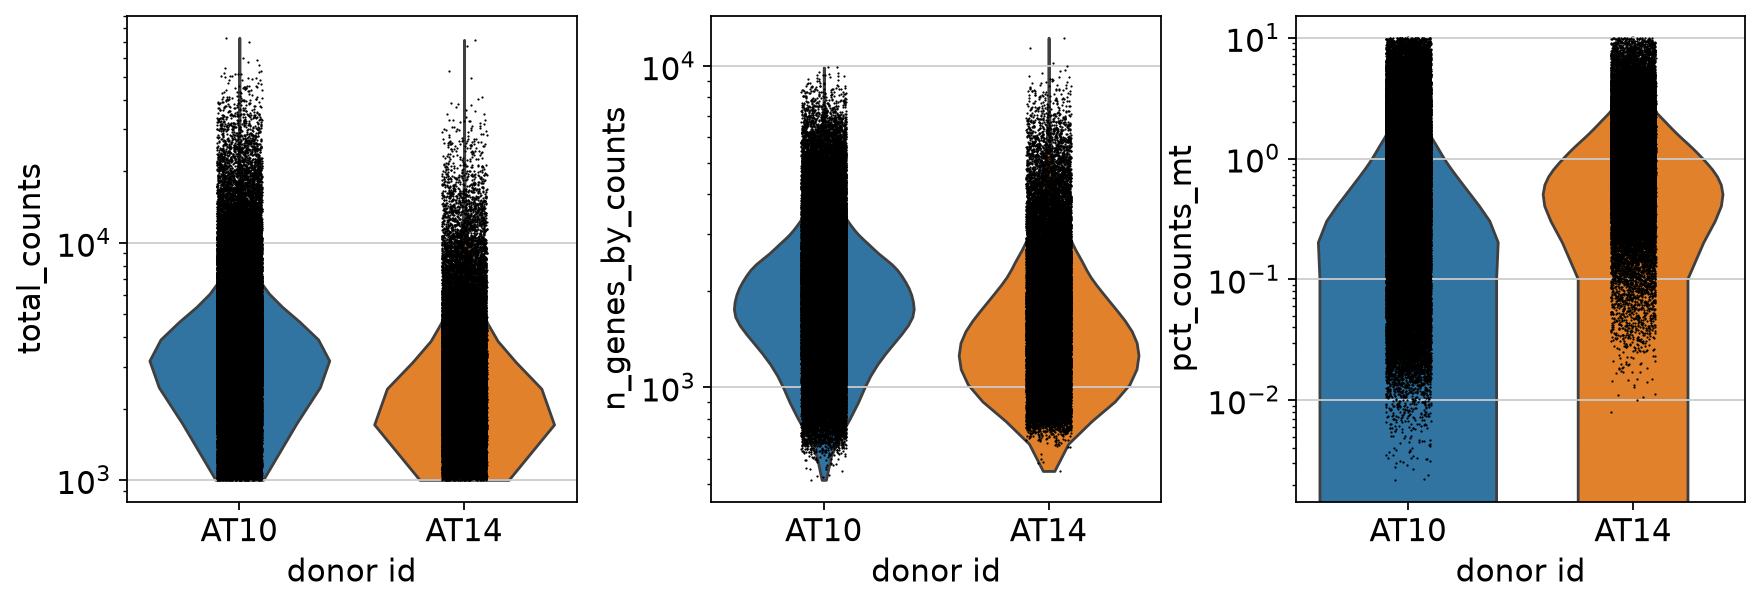

In [18]:
sc.pl.violin(adata, ['total_counts','n_genes_by_counts','pct_counts_mt'], groupby='donor_id', log=True)

So here the donor 14 has less mRNA and was sequenced more poorly so you could capture less number of gene. AT14 has more mitocondrial genes indicating that maybe the nucleuses where not properly extracted 

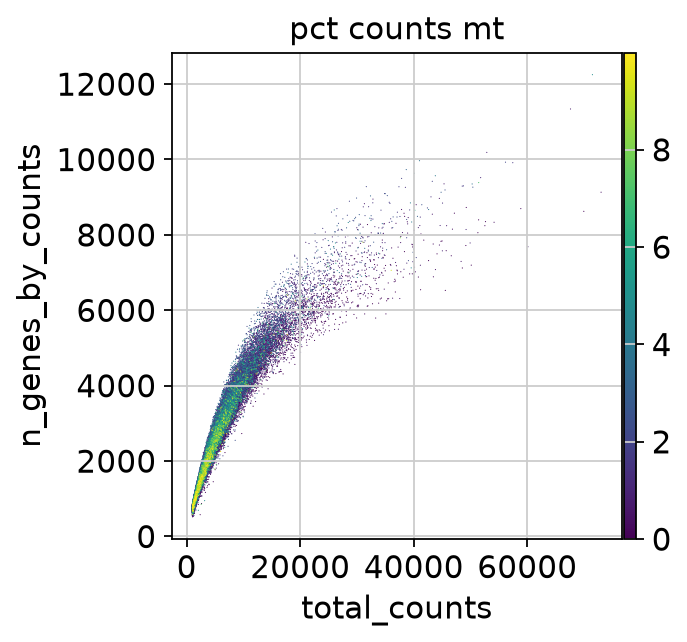

In [19]:
sc.pl.scatter(adata, x='total_counts', y='n_genes_by_counts', color='pct_counts_mt')

So the graph above shows that the more number of counts per cell the more gene types a cell has, this malkes sence, if you sequenced in more depth then you should be able to capture more variability

🔬 **TASK 2.3:** Look at the *floors* of these distributions before choosing thresholds. A standard nuclei-QC recipe removes nuclei with `< ~500` genes, `< ~1000` UMIs, or `> 10%` mito. Check how many nuclei those cuts would actually remove here.

In [20]:
# --- TASK 2.3: inspect the distribution FLOORS before thresholding ---------
# WHAT & WHY: the lower tail marks where real nuclei end and empty/ambient droplets begin.
# HOW: histograms of total_counts and n_genes_by_counts (plt.hist(..., bins=100)) or sc.pl.violin(log=True);
#      note where each distribution bottoms out.
# DOCS: https://scanpy.readthedocs.io/en/stable/generated/scanpy.pl.violin.html


Text(0, 0.5, 'Number of nuclei')

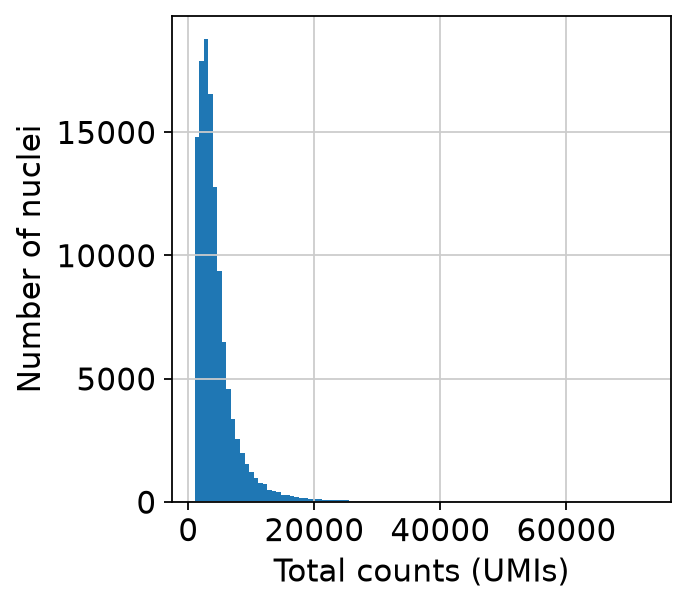

In [21]:
plt.hist(adata.obs['total_counts'], bins=100)
plt.xlabel('Total counts (UMIs)')
plt.ylabel('Number of nuclei')

So here you see thTt there most nuclei have arrond 8,000 counts or total mRNA molecules 


💡 **HINT:** Notice the floors — `total_counts` bottoms out right at ~1000, `n_genes_by_counts` at ~500, and `pct_counts_mt` never exceeds ~10%. That is not a coincidence: **basic per-nucleus QC has already been applied to this dataset**, so the genes/UMI/mito filters remove essentially nothing. That is realistic — you are often handed data that has had a first QC pass. The QC lever that is still meaningful here is **doublet removal**, which has *not* been applied.

🔬 **TASK 2.4:** Apply QC. Keep the standard cuts as explicit guardrails (so the notebook is correct even on un-filtered data), and add a Scrublet doublet cut at `0.25` (the upper tail in the histogram above). Then drop genes seen in `< 3` nuclei. Report nuclei remaining.

Text(0, 0.5, 'Number of nuclei')

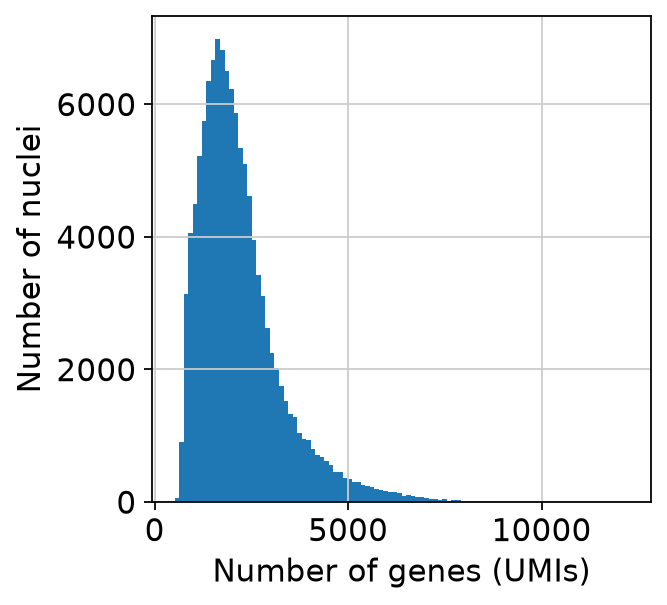

In [22]:
plt.hist(adata.obs['n_genes_by_counts'], bins=100)
plt.xlabel('Number of genes (UMIs)')
plt.ylabel('Number of nuclei')

Here you see that per x number of genes per nuclei

In [23]:
# --- TASK 2.4: apply the QC cuts ------------------------------------------
# WHAT & WHY: drop low-count / low-gene nuclei, high-mito nuclei, and predicted doublets so downstream
#             structure reflects biology, not technical noise.
# HOW: sc.pp.filter_cells(adata, min_counts=...); sc.pp.filter_cells(adata, min_genes=...);
#      sc.pp.filter_genes(adata, min_cells=...); then boolean-mask on pct_counts_mt and the doublet score.
# DOCS: https://scanpy.readthedocs.io/en/stable/generated/scanpy.pp.filter_cells.html
#       https://scanpy.readthedocs.io/en/stable/generated/scanpy.pp.filter_genes.html


In [24]:
sc.pp.filter_cells(adata, min_counts=1000)
adata.obs['donor_id'].value_counts()

donor_id
AT10    85983
AT14    32488
Name: count, dtype: int64

Text(0, 0.5, 'Number of nuclei')

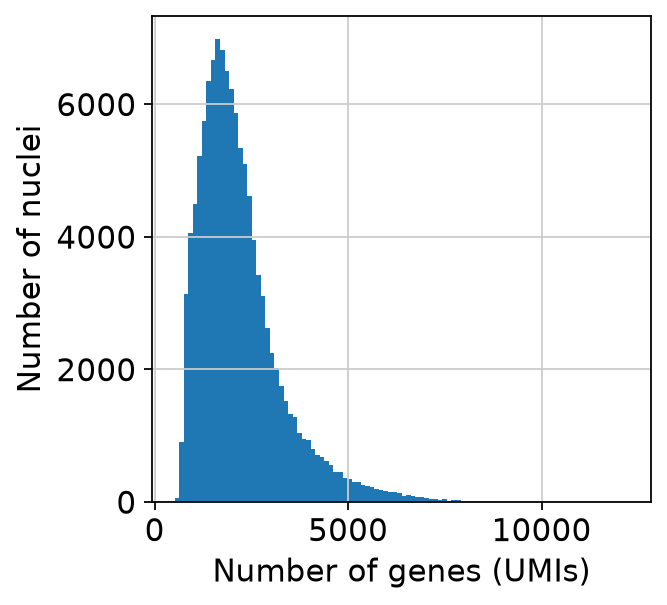

In [25]:
plt.hist(adata.obs['n_genes_by_counts'], bins=100)
plt.xlabel('Number of genes (UMIs)')
plt.ylabel('Number of nuclei')

In [26]:
sc.pp.filter_cells(adata, min_genes=500)

Text(0, 0.5, 'Number of nuclei')

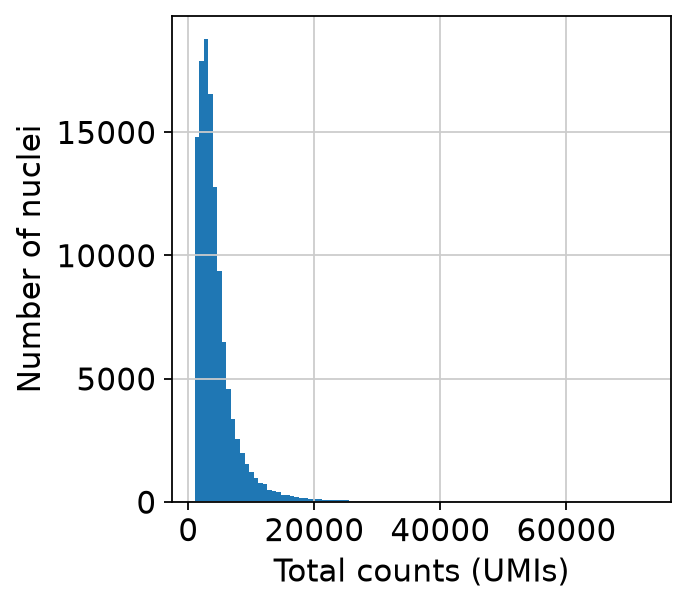

In [27]:
plt.hist(adata.obs['total_counts'], bins=100)
plt.xlabel('Total counts (UMIs)')
plt.ylabel('Number of nuclei')

In [28]:
sc.pp.filter_cells(adata, min_counts=1000)
adata.obs['donor_id'].value_counts()

donor_id
AT10    85983
AT14    32488
Name: count, dtype: int64

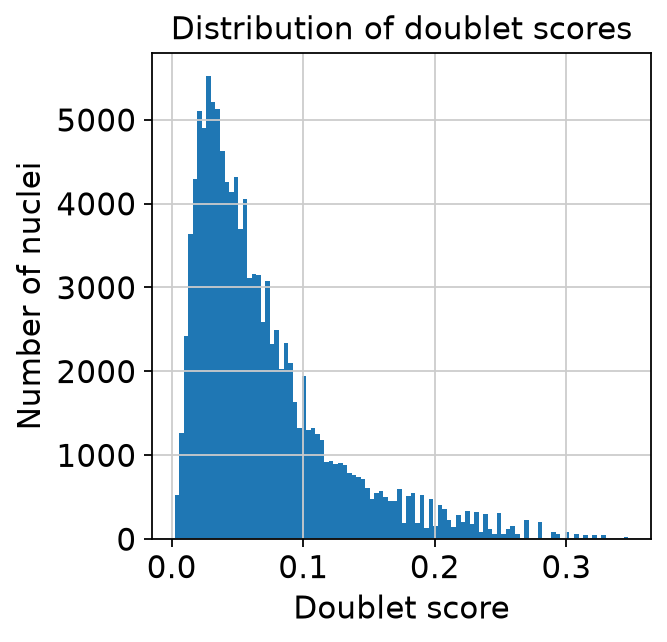

In [29]:
plt.hist(adata.obs['doublet_scores'], bins=100)
plt.xlabel('Doublet score')
plt.ylabel('Number of nuclei')
plt.title('Distribution of doublet scores')
plt.show()

In [30]:
adata[adata.obs['doublet_scores'] < 0.25, :]

View of AnnData object with n_obs × n_vars = 117200 × 36601
    obs: 'cell_id', 'donor_id', 'site_id', 'sample', 'n_genes_by_counts', 'total_counts', 'mt_frac', 'doublet_scores', 'log1p_n_genes_by_counts', 'log1p_total_counts', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'n_counts', 'n_genes'
    var: 'mt', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts'
    uns: 'donor_id_colors'

The double scores looks at cells with many UMI with the same barcode and if its above what it expects from one cell then it gets a high doublet socre, and it also concideres the gene variability, so if you have genes bellonging to two different cell tipes in the same droplet


In [31]:
sc.pp.filter_cells(adata, min_counts=1000)
adata_raw.obs['donor_id'].value_counts()

donor_id
AT10    85983
AT14    32488
Name: count, dtype: int64

Now to eliminate nuclei rich in mitocondrial genes

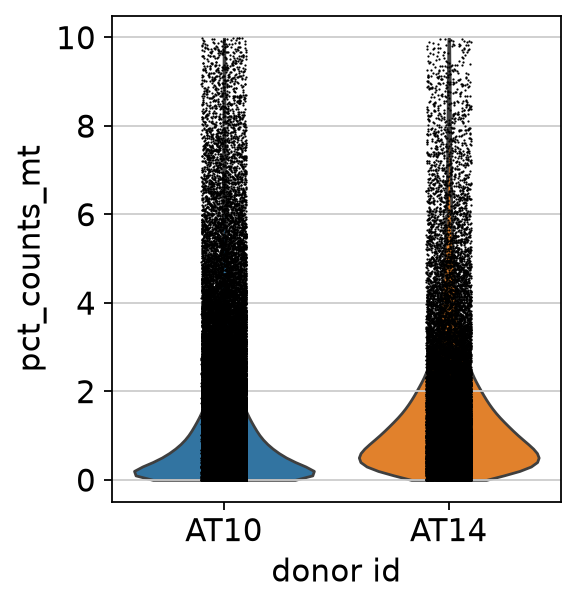

Text(0, 0.5, 'Number of nuclei')

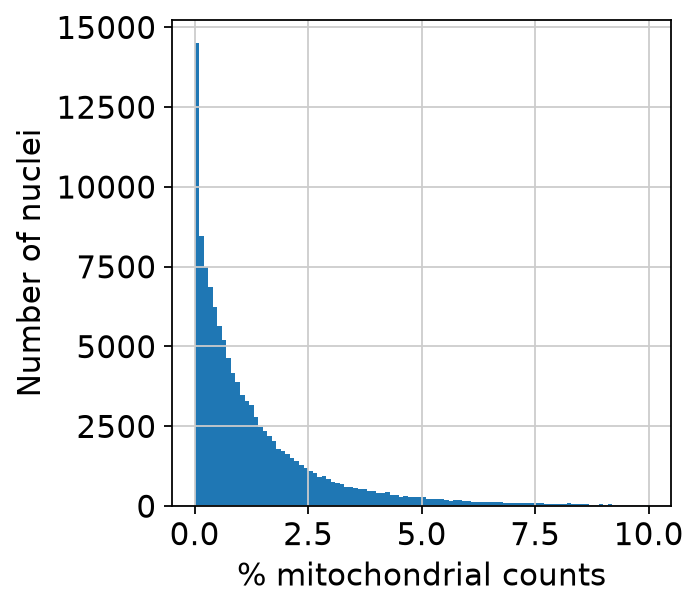

In [32]:
# violin of mito % per donor
sc.pl.violin(adata, ['pct_counts_mt'], groupby='donor_id')

# or a simple histogram
plt.hist(adata.obs['pct_counts_mt'], bins=100)
plt.xlabel('% mitochondrial counts')
plt.ylabel('Number of nuclei')


In [33]:
ndata = adata[adata.obs['pct_counts_mt'] < 2.5, :]

In [34]:
ndata

View of AnnData object with n_obs × n_vars = 99320 × 36601
    obs: 'cell_id', 'donor_id', 'site_id', 'sample', 'n_genes_by_counts', 'total_counts', 'mt_frac', 'doublet_scores', 'log1p_n_genes_by_counts', 'log1p_total_counts', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'n_counts', 'n_genes'
    var: 'mt', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts'
    uns: 'donor_id_colors'

In [35]:
# Compare donor composition: raw (adata_raw) vs after filtering (adata)
comparison = pd.DataFrame({
    'raw':      adata_raw.obs['donor_id'].value_counts(),
    'filtered': ndata.obs['donor_id'].value_counts(),
})
comparison['removed']   = comparison['raw'] - comparison['filtered']
comparison['pct_kept']  = (comparison['filtered'] / comparison['raw'] * 100).round(1)
comparison.loc['TOTAL'] = comparison.sum(numeric_only=True)
comparison.loc['TOTAL', 'pct_kept'] = round(
    comparison.loc['TOTAL', 'filtered'] / comparison.loc['TOTAL', 'raw'] * 100, 1)

print(comparison)


               raw  filtered  removed  pct_kept
donor_id                                       
AT10       85983.0   73225.0  12758.0      85.2
AT14       32488.0   26095.0   6393.0      80.3
TOTAL     118471.0   99320.0  19151.0      83.8


⚠️ **CHECKPOINT:** You should have roughly **116,000–118,000 nuclei** remaining (the doublet cut removes ~1,000–1,500; the genes/UMI/mito cuts remove ~0 because the data was pre-filtered). After the `min_cells=3` gene filter you should keep on the order of **33,000–34,000 genes**. If you lost tens of thousands of nuclei, your thresholds are far too strict for *this* dataset — re-read the floors above.

In [36]:
adata.obs['donor_id'].value_counts()

donor_id
AT10    85983
AT14    32488
Name: count, dtype: int64

In [37]:
ndata.uns
# this is to see the unstructured data without the shape of the data, so we can see what is in the unstructured data.

{'donor_id_colors': array(['#1f77b4', '#ff7f0e'], dtype='<U7')}

## 3. Normalization and feature selection

Raw counts conflate biology with sequencing depth. We library-size-normalize, log-transform, snapshot the result into `.raw` (for marker plotting later), then select highly variable genes (HVGs).

🔬 **TASK 3.1:** Stash raw counts in a layer, then `normalize_total` (target 1e4) + `log1p`, and freeze `.raw`.

In [38]:
# --- 3. Normalization ------------------------------------------------------
# WHAT & WHY: raw counts scale with sequencing depth; normalize + log so nuclei are comparable and variance
#             is stabilised. KEEP raw counts in a layer -- seurat_v3 HVGs and CNV inference need them.
# HOW: adata.layers['counts'] = adata.X.copy(); sc.pp.normalize_total(adata, target_sum=1e4); sc.pp.log1p(adata)
# DOCS: https://scanpy.readthedocs.io/en/stable/generated/scanpy.pp.normalize_total.html
#       https://scanpy.readthedocs.io/en/stable/generated/scanpy.pp.log1p.html


In [39]:
ndata.layers['counts'] = ndata.X.copy()
# this is to keep the raw 
# counts in a layer so that we can use them later for seurat_v3 HVGs and CNV inference.

/tmp/ipykernel_1754858/582179739.py:1: ImplicitModificationWarning: Setting element `.layers['counts']` of view, initializing view as actual.
  ndata.layers['counts'] = ndata.X.copy()


In [40]:
sc.pp.normalize_total(ndata, target_sum=1e4)
# this is to normalize the data so that the total counts for
# each cell are the same, which is important for downstream analysis.

In [41]:
sc.pp.log1p(ndata)
# this is to log transform the data so 
# that the variance is stabilised and the data is more normally distributed, 
# which is important for downstream analysis.

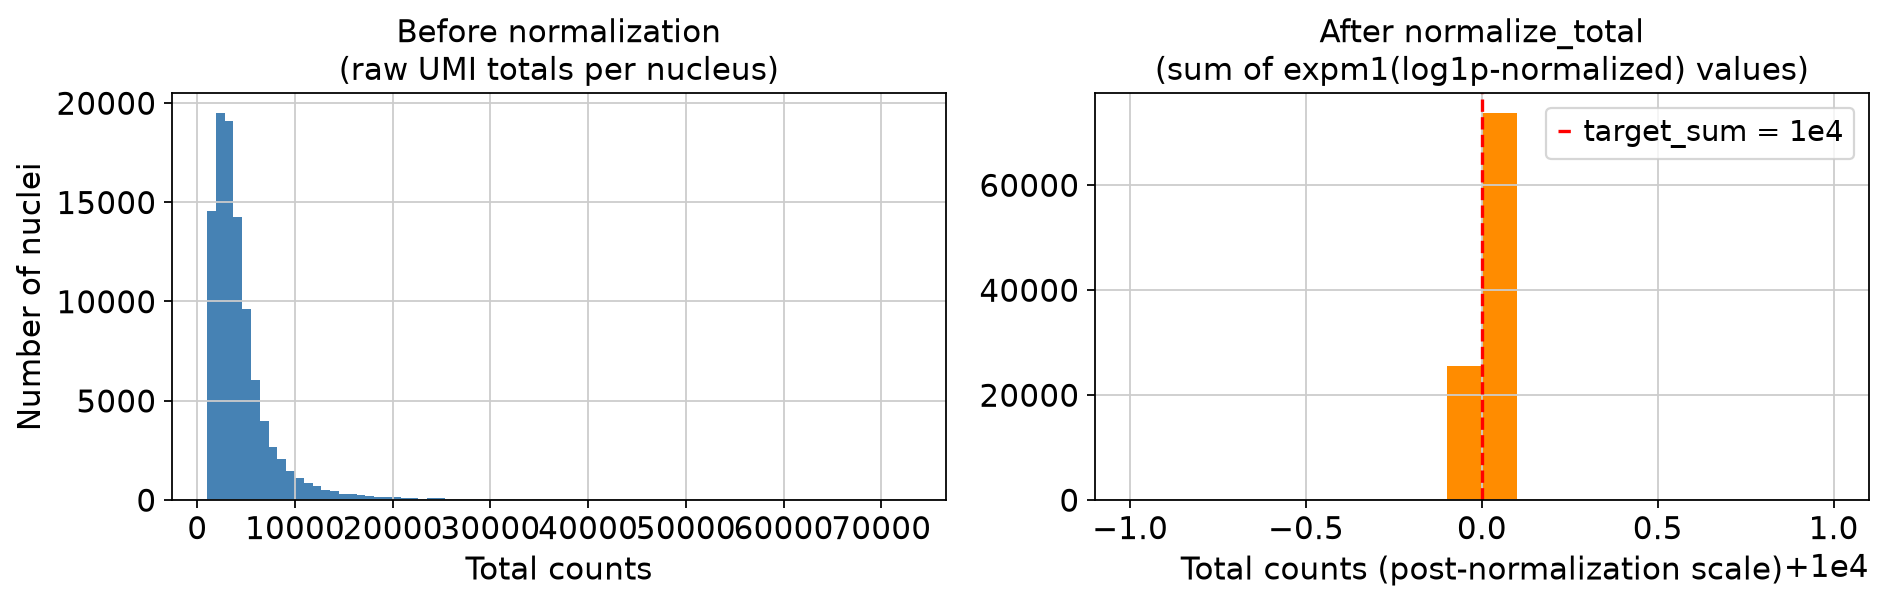

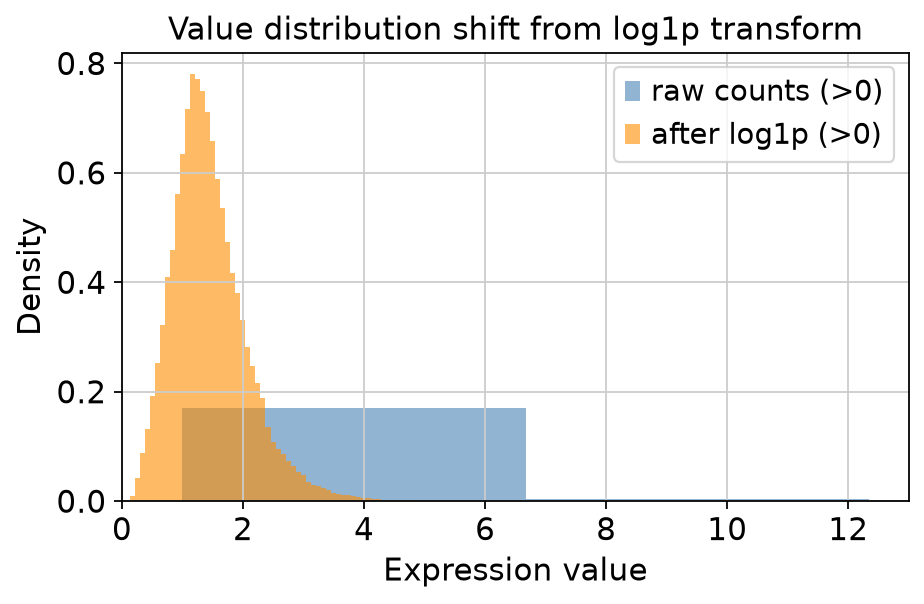

In [42]:
import scipy.sparse as sp

# 1) Per-cell totals before vs after normalize_total (+ reverse log1p to check target_sum effect)
raw_totals = np.asarray(ndata.layers["counts"].sum(axis=1)).ravel()
norm_totals = np.asarray(np.expm1(ndata.X).sum(axis=1)).ravel()  # approx totals after normalize_total

fig, ax = plt.subplots(1, 2, figsize=(12, 4))

ax[0].hist(raw_totals, bins=80, color="steelblue")
ax[0].set_title("Before normalization\n(raw UMI totals per nucleus)")
ax[0].set_xlabel("Total counts")
ax[0].set_ylabel("Number of nuclei")

# robust to near-constant post-normalization totals (especially float32 precision around 1e4)
finite_norm = norm_totals[np.isfinite(norm_totals)]
rng = np.ptp(finite_norm) if finite_norm.size else 0.0
center = float(np.mean(finite_norm)) if finite_norm.size else 1e4

# float32 values near 1e4 cannot support very fine bin widths
ulp = np.spacing(np.float32(center))
requested_bins = 80

if (finite_norm.size == 0) or (rng <= 0) or ((rng / requested_bins) <= ulp):
    ax[1].hist(finite_norm, bins=20, range=(center - 1, center + 1), color="darkorange")
else:
    ax[1].hist(finite_norm, bins=requested_bins, color="darkorange")
ax[1].axvline(1e4, color="red", linestyle="--", label="target_sum = 1e4")
ax[1].set_title("After normalize_total\n(sum of expm1(log1p-normalized) values)")
ax[1].set_xlabel("Total counts (post-normalization scale)")
ax[1].legend()

plt.tight_layout()
plt.show()

# 2) Expression-value distribution before vs after log1p (non-zero entries)
raw_mat = ndata.layers["counts"]
log_mat = ndata.X

raw_vals = raw_mat.data if sp.issparse(raw_mat) else raw_mat[raw_mat > 0]
log_vals = log_mat.data if sp.issparse(log_mat) else log_mat[log_mat > 0]

# optional downsample for faster plotting
n = 300_000
if raw_vals.size > n:
    raw_vals = np.random.choice(raw_vals, n, replace=False)
if log_vals.size > n:
    log_vals = np.random.choice(log_vals, n, replace=False)

plt.figure(figsize=(6, 4))
plt.hist(raw_vals, bins=80, alpha=0.6, label="raw counts (>0)", color="steelblue", density=True)
plt.hist(log_vals, bins=80, alpha=0.6, label="after log1p (>0)", color="darkorange", density=True)
plt.xlim(0, np.percentile(raw_vals, 99))
plt.xlabel("Expression value")
plt.ylabel("Density")
plt.title("Value distribution shift from log1p transform")
plt.legend()
plt.tight_layout()
plt.show()

🔬 **TASK 3.2:** Select ~3000 HVGs with `flavor="seurat_v3"` on the **raw counts layer** (this flavor models mean–variance on counts, not log data), computed per-donor (`batch_key`) so donor-specific genes don't dominate.

In [43]:
# --- TASK 3.2: highly variable genes (seurat_v3) --------------------------
# WHAT & WHY: focus the embedding on the ~3000 most informative genes. seurat_v3 models the mean-variance
#             trend on RAW counts; batch_key selects HVGs per donor to avoid donor-specific genes.
# HOW: sc.pp.highly_variable_genes(adata, flavor='seurat_v3', n_top_genes=3000, layer='counts', batch_key='donor_id')
# DOCS: https://scanpy.readthedocs.io/en/stable/generated/scanpy.pp.highly_variable_genes.html


❓ **QUESTION:** Why do we run `seurat_v3` HVG selection on the *raw counts* layer rather than on the log-normalized matrix? And why pass `batch_key="donor_id"` — what failure mode does that guard against?

## 4. Dimensionality reduction and **donor integration**

We have two donors. If donor identity drives the top axes of variation, clusters will split by patient instead of by biology. We will:
1. scale HVGs → PCA (the uncorrected embedding),
2. run **two** integration methods over PCA/counts keyed on `donor_id` — **Harmony** and **scVI** — and compare them,
3. pick one to carry downstream via an `INTEGRATION_METHOD` flag, keeping *both* embeddings in `.obsm` so the flag works either way.

🔬 **TASK 4.1:** Scale HVGs, run PCA (50 comps), inspect the variance elbow.

In [44]:
# --- 4. Dimensionality reduction ------------------------------------------
# WHAT & WHY: scale HVGs (mean 0, unit variance) so no gene dominates, then PCA to ~50 components;
#             the variance-ratio 'elbow' shows how many PCs carry real signal.
# HOW: on HVGs -> sc.pp.scale(adata, max_value=10); sc.pp.pca(adata, n_comps=50);
#      inspect sc.pl.pca_variance_ratio(adata, n_pcs=50, log=True).
# DOCS: https://scanpy.readthedocs.io/en/stable/generated/scanpy.pp.scale.html
#       https://scanpy.readthedocs.io/en/stable/generated/scanpy.pp.pca.html


In [45]:
sc.pp.scale(ndata, max_value=10)

/shared/projects/tp_2630_ubordeaux_neuromics_184418/envs/single_cell/lib/python3.11/functools.py:909: UserWarning: zero-centering a sparse array/matrix densifies it.
  return dispatch(args[0].__class__)(*args, **kw)


In [46]:
sc.pp.pca(ndata, n_comps=50)

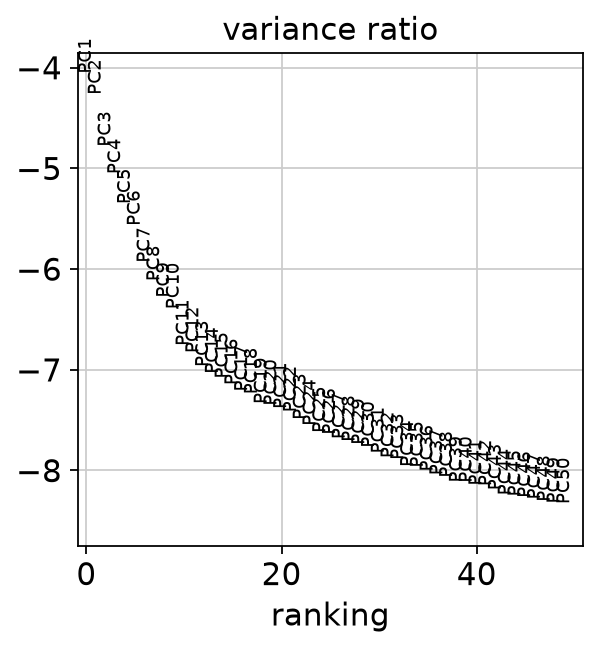

In [47]:
sc.pl.pca_variance_ratio(ndata, n_pcs=50, log=True)

💡 **HINT:** The elbow flattens by ~30 PCs; we use 30 for neighbor graphs throughout. First let's *see* the donor (batch) effect in the uncorrected space.

In [48]:
# --- See the UNCORRECTED structure first ----------------------------------
# WHAT & WHY: build a neighbour graph + UMAP on raw PCA (no integration) so you can SEE the donor batch
#             effect you're about to correct.
# HOW: sc.pp.neighbors(adata, n_pcs=30, use_rep='X_pca'); sc.tl.umap(adata); sc.pl.umap(adata, color='donor_id')
# DOCS: https://scanpy.readthedocs.io/en/stable/generated/scanpy.pp.neighbors.html
#       https://scanpy.readthedocs.io/en/stable/generated/scanpy.tl.umap.html


In [49]:
sc.pp.neighbors(ndata, n_pcs=30, use_rep='X_pca')

In [50]:
sc.tl.umap(ndata)

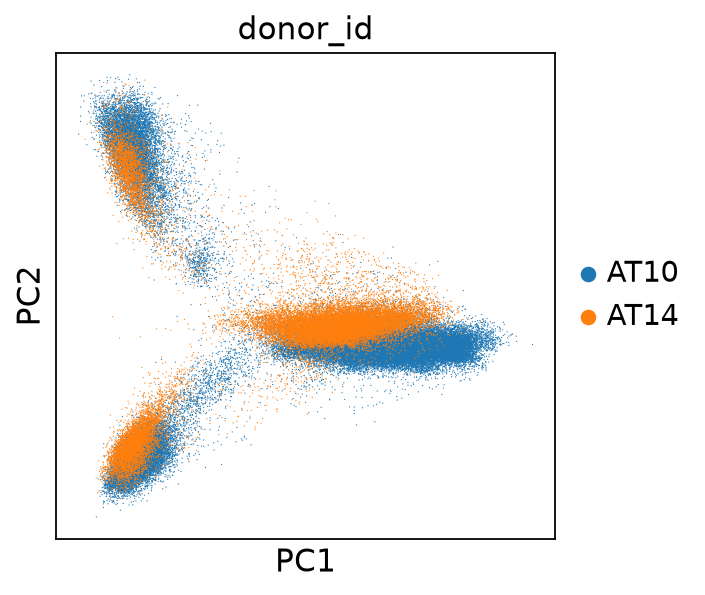

In [51]:
sc.pl.pca(ndata, color='donor_id')


Here you see that the donnor efect (will be the bigest variable change so PCA 1 or 2) is not majour as boithe donnors have each cluster

Bellow is code to visualize the genes that are most contributing to thse PC1 and 2

In [52]:
# Get the genes with the highest loadings (contributions) to PC1 and PC2
pc1_loadings = ndata.varm['PCs'][:, 0]
pc2_loadings = ndata.varm['PCs'][:, 1]

# Get top genes for PC1
top_pc1_genes = ndata.var_names[np.argsort(np.abs(pc1_loadings))[-20:]]
print("Top 20 genes contributing to PC1:")
print(top_pc1_genes.tolist())
print()

# Get top genes for PC2
top_pc2_genes = ndata.var_names[np.argsort(np.abs(pc2_loadings))[-20:]]
print("Top 20 genes contributing to PC2:")
print(top_pc2_genes.tolist())

Top 20 genes contributing to PC1:
['ADGRL3', 'SOX6', 'ST6GALNAC3', 'MBP', 'FRMD4B', 'SOX5', 'DOCK5', 'CDK14', 'GRIK2', 'PLCB1', 'ELMO1', 'CTNNA2', 'GSN', 'NRCAM', 'SPP1', 'PTPRZ1', 'SNTG1', 'NRXN1', 'MAP2', 'GPM6A']

Top 20 genes contributing to PC2:
['ARHGAP15', 'TLR2', 'SYK', 'SAT1', 'RNASET2', 'ADAM28', 'DENND3', 'C3', 'FYB1', 'INPP5D', 'MAGI2', 'LRMDA', 'CD74', 'SLC11A1', 'LNCAROD', 'IL1RAPL1', 'TBXAS1', 'SLCO2B1', 'APBB1IP', 'DOCK8']


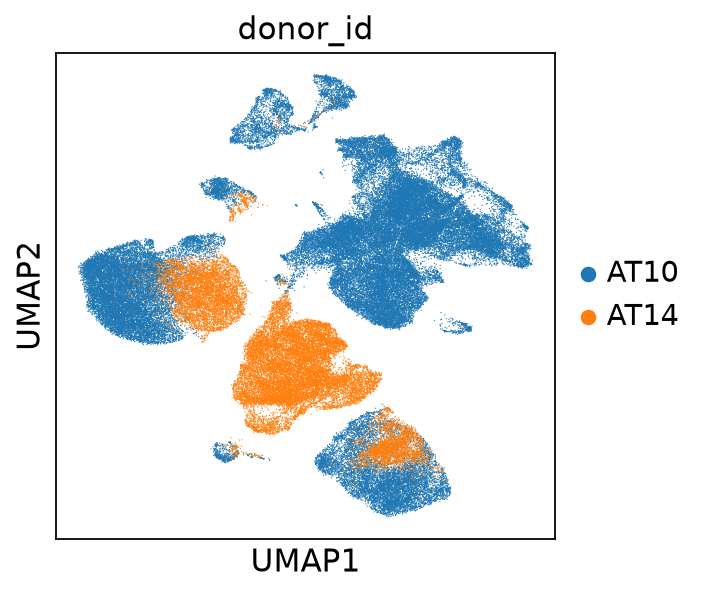

In [53]:
sc.pl.umap(ndata, color='donor_id')

🔬 **TASK 4.2 — Harmony.** Integrate the PCA embedding on `donor_id`. (We call `harmonypy` directly and reshape its output ourselves: the installed `harmonypy`/`scanpy` combination returns `Z_corr` in a shape that the thin `sc.external.pp.harmony_integrate` wrapper mishandles — a good reminder that library version mismatches are a normal part of real analysis.)

In [ ]:
# --- TASK 4.2 -- Harmony integration --------------------------------------
# WHAT & WHY: donors differ technically; Harmony nudges the PCA embedding so shared cell types from
#             different donors overlap, without erasing biology. Fast, operates on PCA space.
# HOW: harmonypy.run_harmony(adata.obsm['X_pca'], adata.obs, ['donor_id']) -> store Z as adata.obsm['X_pca_harmony']
#      (or sc.external.pp.harmony_integrate(adata, 'donor_id')).
# DOCS: https://scanpy.readthedocs.io/en/stable/generated/scanpy.external.pp.harmony_integrate.html
#       https://github.com/slowkow/harmonypy


In [ ]:
import harmonypy
ho = harmonypy.run_harmony(ndata.obsm['X_pca'], ndata.obs, ['donor_id'])  
#here im running the harmony integration on the PCA embedding of the data, 
# using the donor_id as the batch variable. This will help to correct for batch 
# effects between different donors while preserving biological variation.
#and im saving it as ho

2026-07-03 10:08:50,994 - harmonypy - INFO - Running Harmony
2026-07-03 10:08:50,995 - harmonypy - INFO -   Parameters:
2026-07-03 10:08:50,996 - harmonypy - INFO -     max_iter_harmony: 10
2026-07-03 10:08:50,997 - harmonypy - INFO -     max_iter_kmeans: 4
2026-07-03 10:08:50,998 - harmonypy - INFO -     epsilon_cluster: 0.001
2026-07-03 10:08:50,999 - harmonypy - INFO -     epsilon_harmony: 0.01
2026-07-03 10:08:50,999 - harmonypy - INFO -     nclust: 100
2026-07-03 10:08:51,000 - harmonypy - INFO -     block_size: 0.05
2026-07-03 10:08:51,001 - harmonypy - INFO -     lamb: dynamic (alpha=0.2)
2026-07-03 10:08:51,002 - harmonypy - INFO -     theta: [2. 2.]
2026-07-03 10:08:51,003 - harmonypy - INFO -     sigma: [0.1 0.1 0.1 0.1 0.1]...
2026-07-03 10:08:51,004 - harmonypy - INFO -     verbose: True
2026-07-03 10:08:51,004 - harmonypy - INFO -     random_state: 0
2026-07-03 10:08:51,005 - harmonypy - INFO -   Data: 50 PCs × 99320 cells
2026-07-03 10:08:51,005 - harmonypy - INFO -   Bat

2026-07-03 10:08:51,273 - harmonypy - INFO - Computing initial centroids...
2026-07-03 10:08:55,482 - harmonypy - INFO - Initialization complete.
2026-07-03 10:08:55,483 - harmonypy - INFO - Iteration 1 of 10
2026-07-03 10:08:58,969 - harmonypy - INFO - Iteration 2 of 10
2026-07-03 10:09:02,745 - harmonypy - INFO - Iteration 3 of 10
2026-07-03 10:09:06,633 - harmonypy - INFO - Iteration 4 of 10
2026-07-03 10:09:10,522 - harmonypy - INFO - Iteration 5 of 10
2026-07-03 10:09:14,459 - harmonypy - INFO - Converged after 5 iterations


In [ ]:
ndata.obsm["X_pca_harmony"] = ho.Z_corr 
# here im saving the corrected harmony PCA embedding (Z scoreas a new obsm slot in
#  the AnnData object ndata

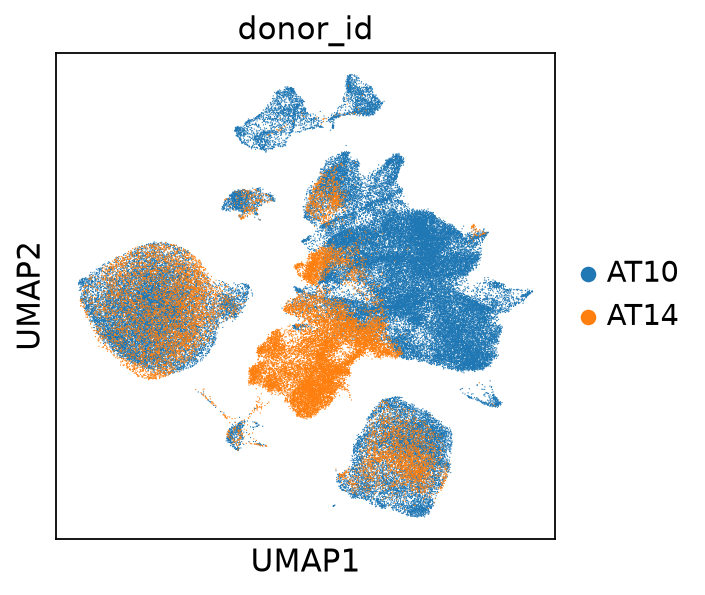

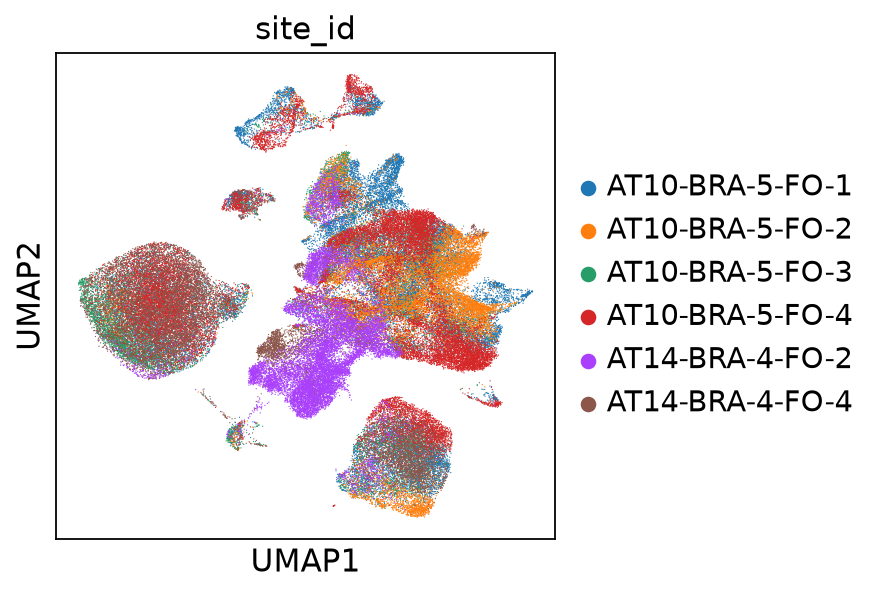

In [ ]:
sc.pp.neighbors(ndata, n_pcs=30, use_rep='X_pca_harmony')
sc.tl.umap(ndata)
sc.pl.umap(ndata, color='site_id')

so im rtuning the umap colored by donnor and i see that my middle cluster is clearly separated
So maybe this is because there are two different cell types given that samples where extracted from different sites
This then lead me to colour cell type by extraction city and I see that all the purple where extracted by a different site


🔬 **TASK 4.3 — scVI.** scVI is a deep generative model trained on raw counts. On CPU it is far slower than Harmony, so **probe per-epoch cost first**, compare against scvi-tools' own epoch heuristic, and cap `max_epochs` so this stays a teaching-friendly runtime (target: well under an hour on CPU).

In [ ]:
# [KEEP-IN-STUDENT]
# scVI integration is a GPU step. It was trained for you (100 epochs) and the 30-dim latent
# was saved -- load it here to skip training. Set TRAIN_SCVI = True to train it yourself (needs a GPU).
import os
TRAIN_SCVI = False
SCVI_LATENT_FILE = "/shared/projects/tp_2630_ubordeaux_neuromics_184418/projects/C10/lederer/gbm_space_proj/precomputed/level1_scvi_latent.npz"

💡 **HINT — runtime caveat.** scVI training cost scales with dataset size and is genuinely slow on CPU for tens of thousands of cells — avoid scvi-tools' automatic epoch heuristic (`get_max_epochs_heuristic`) for a teaching session; in this environment it picked an epoch count that made the full run take well over an hour with no early feedback, which is the wrong trade for a live class. Use a small, **fixed** epoch count instead — you always know your runtime budget up front. Raise it if you have time or GPU access.

In [ ]:
# [KEEP-IN-STUDENT]
SCVI_MAX_EPOCHS = 100   # only used if TRAIN_SCVI = True
if not TRAIN_SCVI:
    if not os.path.exists(SCVI_LATENT_FILE):
        raise FileNotFoundError(
            f"Precomputed scVI latent not found:\n  {SCVI_LATENT_FILE}\n"
            "On a new server you must repoint this path (see CLAUDE.md), or set TRAIN_SCVI = True "
            "if a GPU is available.")
    _d = np.load(SCVI_LATENT_FILE, allow_pickle=True)
    _lat = pd.DataFrame(_d["latent"], index=_d["obs_names"].astype(str))
    _missing = adata.obs_names.difference(_lat.index)
    if len(_missing):
        raise ValueError(
            f"{len(_missing)} of your cells are not in the precomputed scVI latent -- your QC/"
            "filtering differs from the reference run. Re-check the QC steps above (the precomputed "
            "latent covers the reference 117,200-cell set), or set TRAIN_SCVI = True to train yourself.")
    adata.obsm["X_scvi"] = _lat.reindex(adata.obs_names).values.astype("float32")
    print(f"Loaded precomputed scVI latent {adata.obsm['X_scvi'].shape} (skipped GPU training).")
else:
    import scvi, torch
    torch.set_num_threads(8)
    scvi.settings.seed = 0
    scvi_ad = adata.copy()
    scvi.model.SCVI.setup_anndata(scvi_ad, layer="counts", batch_key="donor_id")
    t0 = time.time()
    model = scvi.model.SCVI(scvi_ad, n_latent=30)
    model.train(max_epochs=SCVI_MAX_EPOCHS, early_stopping=False)
    adata.obsm["X_scvi"] = model.get_latent_representation()
    print(f"scVI trained ({SCVI_MAX_EPOCHS} epochs) in {(time.time()-t0)/60:.1f} min")
print("X_scvi shape:", adata.obsm["X_scvi"].shape)

🔬 **TASK 4.4 — compare integrations.** Build a neighbor graph + UMAP for each embedding and inspect donor mixing visually. Then quantify mixing with a simple **neighbor-purity** proxy: for each nucleus, the fraction of its k nearest neighbors from the *same* donor. Under perfect mixing this approaches each donor's global fraction; under no correction it approaches 1.0.

In [ ]:
# --- TASK 4.4 -- compare integrations -------------------------------------
# WHAT & WHY: judge integration by (a) UMAPs coloured by donor and (b) a mixing metric: the fraction of each
#             nucleus's k neighbours from the SAME donor (lower = better mixed, toward each donor's global share).
# HOW: for rep in ('X_pca','X_pca_harmony','X_scvi'): sc.pp.neighbors(use_rep=rep); sc.tl.umap(); store UMAP;
#      sc.pl.embedding(adata, basis=..., color='donor_id'); then the same-donor neighbour fraction (see gbmspace_utils).
# DOCS: https://scanpy.readthedocs.io/en/stable/generated/scanpy.pp.neighbors.html
#       https://scanpy.readthedocs.io/en/stable/generated/scanpy.tl.umap.html


In [ ]:
# --- (continued) finish the integration comparison started above ----------


💡 **HINT:** Both methods pull the mean same-donor neighbor fraction down from the uncorrected value toward the perfect-mixing baseline. For this two-donor teaching run we proceed with **Harmony**: it integrated in seconds (vs minutes for scVI on CPU), gives comparable mixing, and operates on the same interpretable PCA space. We keep `X_scvi` in `.obsm` so you can flip the flag and reproduce everything downstream with scVI instead.

🔬 **TASK 4.5:** Set the integration flag and build the **canonical** neighbor graph + UMAP that all downstream steps use.

In [ ]:
# --- Build the CANONICAL neighbour graph ----------------------------------
# WHAT & WHY: pick the integration you'll carry forward (Harmony here) and build the neighbour graph + UMAP
#             that all clustering and annotation will use.
# HOW: sc.pp.neighbors(adata, n_pcs=30, use_rep='X_pca_harmony'); sc.tl.umap(adata)
# DOCS: https://scanpy.readthedocs.io/en/stable/generated/scanpy.pp.neighbors.html


## 5. Clustering

Leiden community detection on the integrated neighbor graph. We sweep a few resolutions and pick one whose granularity is sensible for broad cell typing.

🔬 **TASK 5.1:** Run Leiden at resolutions 0.3 / 0.5 / 1.0 and compare cluster counts and UMAPs.

In [ ]:
# --- 5. Clustering ---------------------------------------------------------
# WHAT & WHY: Leiden finds communities in the neighbour graph = candidate cell populations. Resolution sets
#             granularity; compare a few and pick one that matches the biology you expect.
# HOW: for r in (0.3, 0.5, 1.0): sc.tl.leiden(adata, resolution=r, key_added=f'leiden_{r}'); compare counts.
# DOCS: https://scanpy.readthedocs.io/en/stable/generated/scanpy.tl.leiden.html


💡 **HINT:** We adopt **resolution 1.0** as the working clustering. Broad cell typing plus a malignant-state axis needs enough granularity to separate (a) the major TME lineages from malignant cells and (b) distinct malignant programs, without shattering into dozens of micro-clusters. Lower resolutions merged biologically distinct populations in this dataset.

In [ ]:
# --- Visualise the clustering ---------------------------------------------
# WHAT & WHY: view the chosen Leiden clusters on the UMAP to sanity-check they're coherent patches.
# HOW: sc.pl.umap(adata, color=['leiden', 'donor_id'])
# DOCS: https://scanpy.readthedocs.io/en/stable/generated/scanpy.pl.umap.html


🔬 **TASK 5.2:** Check each cluster's donor composition — this distinguishes shared biology (both donors) from donor-private populations.

In [ ]:
# --- TASK 5.2 -- donor composition per cluster ----------------------------
# WHAT & WHY: clusters present in BOTH donors are likely shared cell types (immune/vascular);
#             donor-private clusters are often malignant (tumours are patient-specific).
# HOW: pd.crosstab(adata.obs['leiden'], adata.obs['donor_id'], normalize='index') -- inspect / bar-plot.
# DOCS: https://pandas.pydata.org/docs/reference/api/pandas.crosstab.html


## 6. Broad cell-type annotation

We assign each cluster a coarse cell-type label using **two independent lines of evidence**, then reconcile them:
1. **Marker genes** — a curated TME/lineage panel (`gbmspace_utils.TME_MARKERS`), via dotplot and per-cluster gene scores.
2. **CellTypist** — an automated reference classifier; we use the `Developing_Human_Brain` model (a developmental-brain reference, appropriate for glioma whose malignant cells mimic neurodevelopmental programs).

🔬 **TASK 6.1:** Rank marker genes per cluster (Wilcoxon) for a first look at what defines each cluster.

In [ ]:
# --- 6. Cell-type annotation ----------------------------------------------
# WHAT & WHY: rank the genes that most distinguish each cluster -- top markers hint at cell identity.
# HOW: sc.tl.rank_genes_groups(adata, 'leiden', method='wilcoxon'); read with
#      sc.get.rank_genes_groups_df(adata, group=None) or sc.pl.rank_genes_groups(adata).
# DOCS: https://scanpy.readthedocs.io/en/stable/generated/scanpy.tl.rank_genes_groups.html


🔬 **TASK 6.2:** Dotplot the curated TME/lineage marker panel across clusters.

In [ ]:
# --- TASK 6.2 -- marker dotplot -------------------------------------------
# WHAT & WHY: a dotplot of curated lineage/TME markers across clusters is the fastest way to read identities
#             (dot size = % expressing, colour = mean expression).
# HOW: sc.pl.dotplot(adata, marker_dict, groupby='leiden', standard_scale='var')   # marker panel: gbmspace_utils
# DOCS: https://scanpy.readthedocs.io/en/stable/generated/scanpy.pl.dotplot.html


In [ ]:
# --- (continued) finish the marker dotplot started above ------------------


🔬 **TASK 6.3:** Run **CellTypist** with the `Developing_Human_Brain` model on the log-normalized data, then look at the dominant CellTypist call per Leiden cluster.

In [ ]:
# --- TASK 6.3 -- CellTypist annotation ------------------------------------
# WHAT & WHY: transfer labels from a reference atlas (Developing_Human_Brain) as an automated SECOND OPINION
#             to compare against your marker calls. Runs on LOG-NORMALISED data.
# HOW: import celltypist; res = celltypist.annotate(adata, model='Developing_Human_Brain', majority_voting=True)
#      -> add res.predicted_labels to adata.obs. (Model downloads on first use.)
# DOCS: https://celltypist.readthedocs.io/en/latest/celltypist.annotate.html
#       https://celltypist.readthedocs.io/en/latest/notebook/celltypist_tutorial.html


🔬 **TASK 6.4:** Reconcile marker evidence + CellTypist into one coarse `cell_type` per cluster. The cell below prints, for every cluster, its top DE genes, its strongest TME signature, and its CellTypist call side-by-side — the inputs to a manual majority decision.

In [ ]:
# --- TASK 6.4 -- reconcile markers + CellTypist ---------------------------
# WHAT & WHY: neither method is ground truth. Decide ONE coarse cell_type per cluster by combining marker
#             evidence with the majority CellTypist call, breaking ties with the markers you trust.
# HOW: pd.crosstab(adata.obs['leiden'], <celltypist labels>) to see the dominant call per cluster.
#      This is a judgement step -- no single scanpy function.


💡 The reconciliation logic (filled in after reading the table above): clusters whose top markers and TME signature are **microglia** (`P2RY12`, `CX3CR1`), **macrophage/myeloid** (`CD163`, `CD14`), **oligodendrocyte** (`PLP1`, `MOBP`, `ST18`), **neuronal** (`RBFOX3`, `GAD1/2`, `SLC17A7`), **lymphocyte** (`CD3E`, `CD2`), or **vascular** (`CLDN5`, `PDGFRB`) are clearly non-malignant TME. The remaining large clusters express glial/progenitor programs (`SLC1A3`, `GFAP`, `EGFR`, `PDGFRA`, `OLIG1/2`) and CellTypist calls them glioblast / radial-glia / OPC — these are the candidate **malignant** populations (to be confirmed by copy-number inference in Section 7). The dictionary below encodes that per-cluster decision.

🔬 **TASK 6.5:** Encode the per-cluster label decision and write the `cell_type` column.

In [ ]:
# --- Write the cell_type labels -------------------------------------------
# WHAT & WHY: turn your per-cluster decision into a nucleus-level adata.obs['cell_type'] used everywhere downstream.
# HOW: mapping = {'0':'...', '1':'...'}; adata.obs['cell_type'] = adata.obs['leiden'].map(mapping).astype('category')


In [ ]:
# --- (continued) finish encoding the cell_type labels --------------------


❓ **QUESTION:** Where did marker-based and CellTypist calls *disagree*, and how did you break the tie? CellTypist was trained on developing (normal) brain — why is it expected to label malignant glioma cells as "glioblast" / "radial glia" / "OPC", and why is that *useful* rather than a failure?

## 7. Malignant vs TME — copy-number inference

Glioma cells carry large-scale **copy-number alterations (CNAs)** — whole-arm gains/losses absent from normal brain cells. We infer per-nucleus CNA profiles from expression with **infercnvpy**, using clearly-normal TME clusters as the diploid **reference**. Malignant cells show stronger genome-wide CNA signal *and* higher correlation to the average malignant profile.

🔬 **TASK 7.1:** Attach gene chromosomal positions (GRCh38) to `.var` — infercnvpy needs `chromosome`, `start`, `end` to order genes along the genome.

In [ ]:
# --- 7. Malignant vs TME: copy-number inference ---------------------------
# WHAT & WHY: inferCNV needs each gene's chromosome + position to scan for gains/losses along the genome.
#             Attach a GRCh38 gene-position table to adata.var (chromosome, start, end).
# HOW: load reference/grch38_gene_positions.parquet and join onto adata.var by gene symbol; infercnvpy expects
#      adata.var['chromosome'], ['start'], ['end'].
# DOCS: https://infercnvpy.readthedocs.io/en/latest/tutorials.html


🔬 **TASK 7.2:** Pick the unambiguous TME clusters as the CNA reference and run `infercnvpy`.

In [ ]:
# --- TASK 7.2 -- run inferCNV ---------------------------------------------
# WHAT & WHY: malignant cells carry large-scale copy-number aberrations; averaging expression along the genome
#             reveals them. Use KNOWN-normal clusters (TME: immune/vascular) as the reference baseline.
# HOW: import infercnvpy as cnv
#      cnv.tl.infercnv(adata, reference_key='cell_type', reference_cat=[<your TME types>], window_size=250)
#      then cnv.pl.chromosome_heatmap(adata, groupby='cell_type') to view.
# DOCS: https://infercnvpy.readthedocs.io/en/latest/generated/infercnvpy.tl.infercnv.html
#       https://infercnvpy.readthedocs.io/en/latest/infercnv.html


🔬 **TASK 7.3:** Build a per-nucleus **CNA correlation** = correlation of each nucleus's CNA profile to the mean profile of high-CNA nuclei (a malignant-consensus profile). Malignant cells score high on *both* CNA signal and CNA correlation.

In [ ]:
# --- TASK 7.3 -- per-nucleus CNA correlation ------------------------------
# WHAT & WHY: a robust malignant score -- correlate each nucleus's CNA profile (adata.obsm['X_cnv']) against the
#             AVERAGE malignant CNA profile. High correlation = carries the tumour's copy-number signature.
# HOW: build a malignant-mean X_cnv template, then correlate every nucleus to it (numpy). See gbmspace_utils
#      for a helper -- there is no single scanpy call for this.


💡 **HINT — thresholds, and an honest caveat about the source.** A common cell-level malignant call combines a CNA-signal cut with a CNA-correlation cut (order-of-magnitude: signal `> ~0.02`, correlation `> ~0.3`). For the **cluster-level** "is this cluster malignant" call, the standard is a fraction-of-malignant-cells cut (we use `> 20%`).

⚠️ Worth knowing for later: published CNA pipelines are not always internally consistent. The kind of methods text these thresholds come from will sometimes state one cluster-level cutoff (e.g. "≥ 3% malignant") while the *figure legend* of the same work states another (e.g. "≥ 5%"). We flag this not to be pedantic but because **real papers contain exactly these small inconsistencies** — part of learning to read them critically is noticing when the methods and the figures disagree, and deciding for yourself.

⚠️ **A second, bigger caveat, found by actually running this at full scale**: the absolute signal cut `~0.02` turned out not to transfer to this exact pipeline/platform (snRNA-seq nuclei, this window/step, this normalization) at all — on the real 117,200-nucleus data, even genuinely diploid reference cells and the most CNA-elevated candidate-malignant clusters all sit within a narrow 0.005-0.02 band, so a literal `0.02` cut calls almost nothing malignant. This is exactly the kind of pipeline-to-pipeline absolute-threshold mismatch that's common with RNA-based CNA inference — the fix is to **calibrate the signal cut against your own reference population** instead of trusting an external absolute number: take a high percentile (here, the 75th) of the *known-diploid reference cells'* own signal distribution as "what counts as elevated here." The correlation cut (`> 0.3`) wasn't shown to have this problem, so it's kept as-is.

🔬 **TASK 7.4:** Classify nuclei (cell-level) and clusters (cluster-level), and set a derived `cell_status`.

In [ ]:
# --- Classify malignant vs TME -------------------------------------------
# WHAT & WHY: turn the continuous CNA signal into calls at BOTH levels -- per nucleus AND per cluster (cluster
#             majority is more robust). Calibrate the cutoff from the known-diploid TME rather than a magic number.
# HOW: threshold the CNA correlation (e.g. > 75th percentile of reference-TME nuclei) -> adata.obs['malignant'];
#      also take a per-cluster majority vote. (see the HINT above + gbmspace_utils)


In [ ]:
# --- (continued) finish the malignant/TME classification -----------------


⚠️ **CHECKPOINT:** With two adult glioma donors you should land on a **malignant majority** — very roughly **55–65% of nuclei malignant**, the rest TME (dominated by oligodendrocytes and myeloid cells). If you got almost everything malignant or almost nothing, re-check (a) your reference clusters in 7.2, (b) that gene positions attached in 7.1, and (c) that `SIGNAL_CUT` is actually calibrated against your reference cells' own signal distribution (7.4) rather than a fixed absolute number — an absolute cut tends to silently fail across pipelines/platforms, exactly the failure mode this checkpoint is here to catch.

## 8. The malignant cell-state axis

This is the conceptual core. Malignant glioma cells are not a set of discrete types but occupy a **continuum of states** mimicking neurodevelopmental and reactive-glial programs. We score each malignant nucleus against a panel of state signatures (`MALIGNANT_AXIS_MARKERS`), assign each its dominant state, then collapse to four major classes via `MAJOR_CLASS_OF`.

🔬 **TASK 8.1:** Subset to malignant nuclei and score the state signatures with the project helper `score_axis()`.

In [ ]:
# --- 8. Malignant cell-state axis -----------------------------------------
# WHAT & WHY: malignant cells aren't uniform -- they sit on a developmental -> gliosis/hypoxia axis. Score each
#             nucleus for the published state signatures to place it on that axis.
# HOW: subset to malignant nuclei; for each signature: sc.tl.score_genes(adata_mal, gene_list, score_name=state)
# DOCS: https://scanpy.readthedocs.io/en/stable/generated/scanpy.tl.score_genes.html


🔬 **TASK 8.2:** Assign each nucleus its dominant state (`assign_dominant_state`), then map to the 4 major classes.

In [ ]:
# --- TASK 8.2 -- assign the dominant state --------------------------------
# WHAT & WHY: give each malignant nucleus its top-scoring state, then collapse fine states into the paper's
#             4 major classes for an interpretable composition.
# HOW: argmax across the state-score columns -> dominant state (gbmspace_utils.assign_dominant_state);
#      map fine state -> major class with the provided dict.


In [ ]:
# --- (continued) finish assigning states / major classes -----------------


🔬 **TASK 8.3:** Dotplot the state-signature scores per dominant state to confirm each state is driven by its own markers.

In [ ]:
# --- TASK 8.3 -- state-score dotplot --------------------------------------
# WHAT & WHY: confirm each dominant-state group is actually driven by its own signature (the diagonal should pop).
# HOW: sc.pl.dotplot(adata_mal, state_score_columns, groupby='dominant_state')
# DOCS: https://scanpy.readthedocs.io/en/stable/generated/scanpy.pl.dotplot.html


🔬 **TASK 8.4 (bonus — myth-busting).** "Mesenchymal-like" glioma states are sometimes framed as classical EMT. Check whether canonical **EMT regulators** (`EMT_MARKERS`: `SNAI1/2`, `TWIST1/2`, `ZEB1/2`) are actually specific to the gliosis/hypoxia states here.

In [ ]:
# --- TASK 8.4 (bonus) -- EMT myth-busting ---------------------------------
# WHAT & WHY: test whether classical EMT regulators (SNAI1/2, TWIST1/2, ZEB1/2) are SPECIFICALLY high in the
#             gliosis/hypoxia states -- the paper argues they are not, so 'mesenchymal-like' is a misnomer.
# HOW: sc.tl.score_genes(adata_mal, ['SNAI1','SNAI2','TWIST1','TWIST2','ZEB1','ZEB2'], score_name='EMT');
#      compare across dominant states (violin/dotplot).
# DOCS: https://scanpy.readthedocs.io/en/stable/generated/scanpy.tl.score_genes.html


❓ **QUESTION:** Are the classical EMT regulators strongly and *specifically* up in the gliosis/hypoxia (AC-gliosis-hypoxia) class, or are they weak/diffuse across all states? What does that imply about calling these states "mesenchymal" in the EMT sense?

## 9. Composition and differential expression

🔬 **TASK 9.1:** Write the malignant-state labels back onto the full object and compare cell-type and malignant-class composition between the two donors.

In [ ]:
# --- 9. Composition and differential expression ---------------------------
# WHAT & WHY: propagate the malignant-state labels from the subset back onto the FULL object so every nucleus
#             has a final label (malignant state, or TME cell_type) for composition/DE.
# HOW: map states back by index: adata.obs.loc[mal_index, 'malignant_state'] = ...; fill the rest from cell_type.


🔬 **TASK 9.2:** Pick one DE comparison. We contrast the two largest malignant major classes (Wilcoxon) and report top markers + a volcano.

In [ ]:
# --- TASK 9.2 -- differential expression ----------------------------------
# WHAT & WHY: find genes distinguishing two malignant classes to characterise them molecularly.
# HOW: sc.tl.rank_genes_groups(adata, 'malignant_state', groups=[A], reference=B, method='wilcoxon');
#      read with sc.get.rank_genes_groups_df or sc.pl.rank_genes_groups.
# DOCS: https://scanpy.readthedocs.io/en/stable/generated/scanpy.tl.rank_genes_groups.html


In [ ]:
# --- (continued) finish / plot the DE result -----------------------------


## 10. Publication-quality summary figure

🔬 **TASK 10.1:** Assemble a single multi-panel figure synthesizing the analysis: the cell-type map, the malignant/TME split, and the malignant-state axis.

In [ ]:
# --- 10. Summary figure ---------------------------------------------------
# WHAT & WHY: assemble ONE multi-panel figure telling the story (UMAP by cell_type, malignant map, state axis,
#             composition). Synthesis, not new computation.
# HOW: fig, axes = plt.subplots(...); sc.pl.umap(adata, color=..., ax=ax, show=False) per panel.
# DOCS: https://scanpy.readthedocs.io/en/stable/generated/scanpy.pl.umap.html


## 11. Save the annotated reference

This annotated object becomes the **reference for Level 2** (spatial deconvolution). We save it with clean, well-named `.obs` columns and both integration embeddings retained.

🔬 **TASK 11.1:** Restore full genes, tidy `.obs`, and write the annotated AnnData to `data/processed/`.

In [ ]:
# --- 11. Save the annotated reference -------------------------------------
# WHAT & WHY: this annotated object IS the input to Level 2 (the cell2location reference). Restore all genes,
#             tidy .obs, then write it out.
# HOW: adata.write_h5ad('<.../data/processed/gbm_l1_snrna_AT10_AT14_annotated.h5ad>')  # path is in the notebook
# DOCS: https://anndata.readthedocs.io/en/stable/generated/anndata.AnnData.write_h5ad.html


## Summary

You have, from raw counts and no labels:
1. ✅ QC'd the nuclei (discovering basic QC was pre-applied; added doublet removal)
2. ✅ Normalized, selected HVGs, and **integrated two donors** with Harmony and scVI (compared)
3. ✅ Clustered and annotated **broad cell types** (markers + CellTypist, reconciled)
4. ✅ Split **malignant vs TME** by copy-number inference
5. ✅ Characterised a continuous **malignant cell-state axis** and its per-donor composition
6. ✅ Run a DE comparison and built a publication figure
7. ✅ Saved a clean annotated reference for Level 2

**Carry into Level 2:** which malignant states did you find, and how were they distributed between donors? Level 2 asks *where* in the tissue these states live — and is where the dataset's origin is finally revealed.

---